# Lab 4: Gradient Descent Optimization

### Objectives
1. Understand the principle and mathematics of gradient descent.
2. Generate synthetic data using `make_regression` and fit linear regression with gradient descent.
3. Implement and visualize 1D and 2D gradient descent algorithms.
4. Analyze the effect of learning rates on convergence.

## Part A: Introduction

### 1. Gradient Descent Concept
Gradient descent is an iterative optimization algorithm used to find a local minimum of a differentiable function.

Update formula:
$$x^{(t+1)} = x^{(t)} - \eta \nabla f(x^{(t)})$$

Where:
- $x^{(t)}$ is the current parameter value at iteration $t$.
- $\eta$ is the learning rate (step size).
- $\nabla f(x^{(t)})$ is the gradient (derivative) of the function at $x^{(t)}$.

### 2. Convex vs Non-Convex Functions
- **Convex Functions:** Have a single global minimum (bowl shape); gradient descent is guaranteed to converge to the optimal solution.
- **Non-Convex Functions:** Have multiple local minima, saddle points, and plateaus where optimization can get trapped.

### 3. Importance of Learning Rate ($\eta$)
The learning rate controls the step size taken during each update:
- **Too small ($\eta \ll 1$):** Convergence is very slow and requires excessive iterations.
- **Too large ($\eta \gg 1$):** Steps can overshoot the minimum, oscillate, or diverge.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

## Part B: Linear Regression with Gradient Descent

### 1. Dataset Generation using `make_regression`
Generate a synthetic 1D linear regression dataset with 100 samples and added Gaussian noise.

In [11]:
# generate synthetic linear regression data
X_raw, y_raw = make_regression(n_samples=100, n_features=1, noise=10.0, random_state=42)

# flatten arrays for simple 1d calculations
x_data = X_raw.flatten()
y_data = y_raw

print(f"Dataset generated: {len(x_data)} samples")
print(f"First 5 x values: {np.round(x_data[:5], 3)}")
print(f"First 5 y values: {np.round(y_data[:5], 3)}")


Dataset generated: 100 samples
First 5 x values: [ 0.931  0.087 -1.058  0.314 -0.479]
First 5 y values: [ 50.78  -10.065 -34.918  10.527 -17.738]


### 2. Gradient Descent on the Regression Dataset
Fit linear model $\hat{y} = w \cdot x + b$ by minimizing Mean Squared Error (MSE):
$$J(w, b) = \frac{1}{n}\sum_{i=1}^n (\hat{y}_i - y_i)^2$$

In [3]:
def compute_mse(w, b, x, y):
    predictions = w * x + b
    return np.mean((predictions - y) ** 2)


def gradient_descent_regression(x, y, learning_rate, num_iterations):
    n = len(x)
    w = 0.0
    b = 0.0
    loss_history = []

    for _ in range(num_iterations):
        predictions = w * x + b
        error = predictions - y

        # compute partial derivatives
        grad_w = (2 / n) * np.sum(error * x)
        grad_b = (2 / n) * np.sum(error)

        # update parameters
        w = w - learning_rate * grad_w
        b = b - learning_rate * grad_b

        loss_history.append(compute_mse(w, b, x, y))

    return w, b, loss_history


# train linear regression model with gradient descent
learning_rate_reg = 0.05
iterations_reg = 100

learned_w, learned_b, loss_history = gradient_descent_regression(
    x_data, y_data, learning_rate_reg, iterations_reg
)

print(f"Trained weight (slope w): {learned_w:.4f}")
print(f"Trained bias (intercept b): {learned_b:.4f}")
print(f"Final MSE Loss: {loss_history[-1]:.4f}")

Trained weight (slope w): 44.4259
Trained bias (intercept b): 1.1601
Final MSE Loss: 78.0544


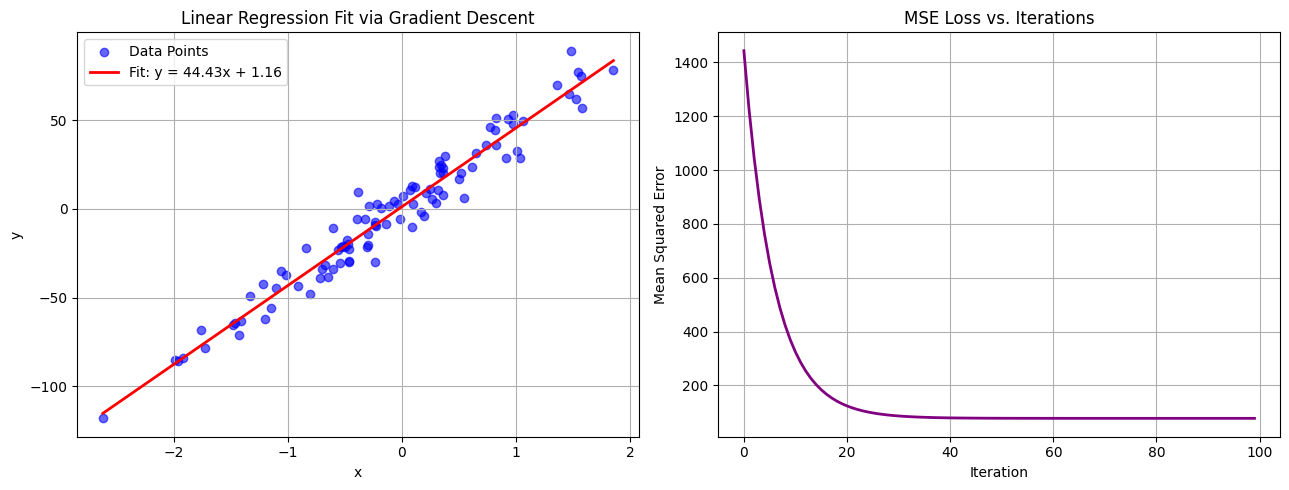

In [4]:
# plot dataset with fitted line and loss curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 1. regression fit
ax1.scatter(x_data, y_data, color="blue", alpha=0.6, label="Data Points")
x_line = np.linspace(x_data.min(), x_data.max(), 100)
y_line = learned_w * x_line + learned_b
ax1.plot(x_line, y_line, color="red", linewidth=2, label=f"Fit: y = {learned_w:.2f}x + {learned_b:.2f}")
ax1.set_title("Linear Regression Fit via Gradient Descent")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.grid(True)
ax1.legend()

# 2. loss convergence
ax2.plot(loss_history, color="purple", linewidth=2)
ax2.set_title("MSE Loss vs. Iterations")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Mean Squared Error")
ax2.grid(True)

plt.tight_layout()
plt.show()

## Part C: Function Optimization Experiments

### Exercise 1: Basic Gradient Descent (1D Quadratic Function)
Minimize the 1D quadratic function $f(x) = (x - 3)^2$ with derivative $f'(x) = 2(x - 3)$.

In [5]:
def cost_function_1d(x):
    return (x - 3) ** 2


def gradient_1d(x):
    return 2 * (x - 3)


def gradient_descent_1d(starting_x, learning_rate, num_iterations):
    history = [starting_x]
    current_x = starting_x

    for _ in range(num_iterations):
        current_x = current_x - learning_rate * gradient_1d(current_x)
        history.append(current_x)

    return current_x, history


# run gradient descent
initial_x = -2.0
learning_rate = 0.1
num_iterations = 25

optimal_x, x_history = gradient_descent_1d(initial_x, learning_rate, num_iterations)

print(f"Starting x0: {initial_x}")
print(f"Optimal x found: {optimal_x:.4f}")
print(f"Minimum cost f(x): {cost_function_1d(optimal_x):.4f}")

Starting x0: -2.0
Optimal x found: 2.9811
Minimum cost f(x): 0.0004


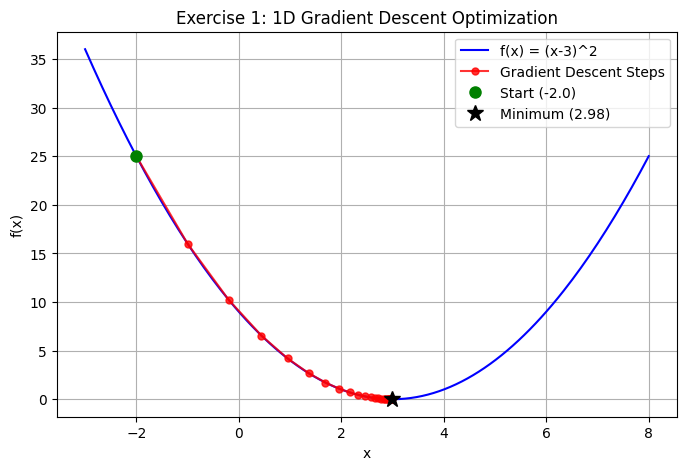

In [6]:
# plot function curve and gradient descent trajectory
x_values = np.linspace(-3, 8, 200)
y_values = cost_function_1d(x_values)
history_y = [cost_function_1d(x) for x in x_history]

plt.figure(figsize=(8, 5))
plt.plot(x_values, y_values, label="f(x) = (x-3)^2", color="blue")
plt.plot(x_history, history_y, "ro-", label="Gradient Descent Steps", markersize=5, alpha=0.8)
plt.plot(x_history[0], history_y[0], "go", markersize=8, label=f"Start ({x_history[0]})")
plt.plot(optimal_x, cost_function_1d(optimal_x), "k*", markersize=12, label=f"Minimum ({optimal_x:.2f})")

plt.title("Exercise 1: 1D Gradient Descent Optimization")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

### Exercise 2: Learning Rate Effect
Compare the convergence behavior on $f(x) = (x - 3)^2$ using learning rates: $\eta = 0.01$, $\eta = 0.1$, $\eta = 0.5$, and $\eta = 1.05$.

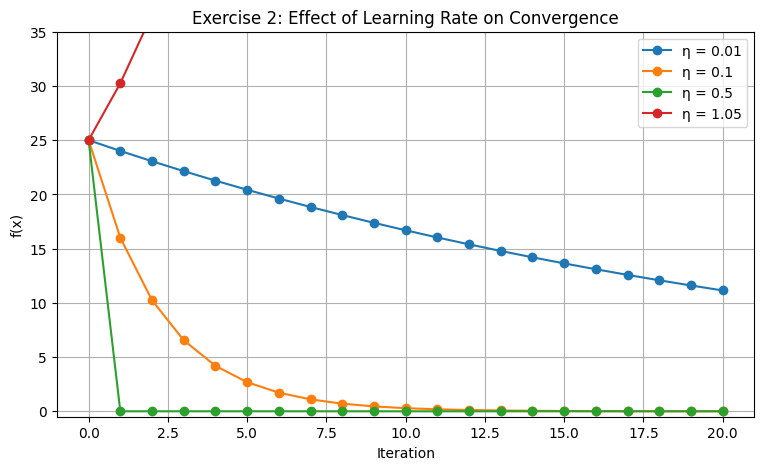

In [7]:
learning_rates = [0.01, 0.1, 0.5, 1.05]
num_iterations = 20
initial_x = -2.0

plt.figure(figsize=(9, 5))

for lr in learning_rates:
    _, history = gradient_descent_1d(initial_x, lr, num_iterations)
    cost_history = [cost_function_1d(x) for x in history]
    plt.plot(cost_history, marker="o", label=f"η = {lr}")

plt.title("Exercise 2: Effect of Learning Rate on Convergence")
plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.ylim(-0.5, 35)
plt.grid(True)
plt.legend()
plt.show()

### Exercise 2: Questions & Analysis
- **Which learning rate converges faster?**
  - $\eta = 0.5$ converges fastest (in exactly 1 step), reaching the exact minimum at $x = 3$.
  - $\eta = 0.1$ converges smoothly and stably within ~15 iterations.
  - $\eta = 0.01$ converges slowly, needing significantly more iterations.
- **Which diverges?**
  - $\eta = 1.05$ diverges because the step size is too large, causing the algorithm to overshoot the minimum with increasing oscillations at each step.

### Exercise 3: Gradient Descent in 2D
Minimize the 2D function $f(x, y) = x^2 + 2y^2$ with gradient $\nabla f(x, y) = (2x, 4y)$ and visualize trajectory using a contour plot.

In [8]:
def cost_function_2d(x, y):
    return x**2 + 2 * (y**2)


def gradient_2d(x, y):
    grad_x = 2 * x
    grad_y = 4 * y
    return grad_x, grad_y


def gradient_descent_2d(start_x, start_y, learning_rate, num_iterations):
    history_x = [start_x]
    history_y = [start_y]
    curr_x, curr_y = start_x, start_y

    for _ in range(num_iterations):
        grad_x, grad_y = gradient_2d(curr_x, curr_y)
        curr_x = curr_x - learning_rate * grad_x
        curr_y = curr_y - learning_rate * grad_y
        history_x.append(curr_x)
        history_y.append(curr_y)

    return curr_x, curr_y, history_x, history_y


# run 2d gradient descent
start_x, start_y = 4.0, 3.0
learning_rate_2d = 0.1
num_iterations_2d = 20

final_x, final_y, hist_x, hist_y = gradient_descent_2d(
    start_x, start_y, learning_rate_2d, num_iterations_2d
)

print(f"Starting point: ({start_x}, {start_y})")
print(f"Optimal coordinates found: (x = {final_x:.4f}, y = {final_y:.4f})")
print(f"Minimum cost f(x, y): {cost_function_2d(final_x, final_y):.4f}")

Starting point: (4.0, 3.0)
Optimal coordinates found: (x = 0.0461, y = 0.0001)
Minimum cost f(x, y): 0.0021


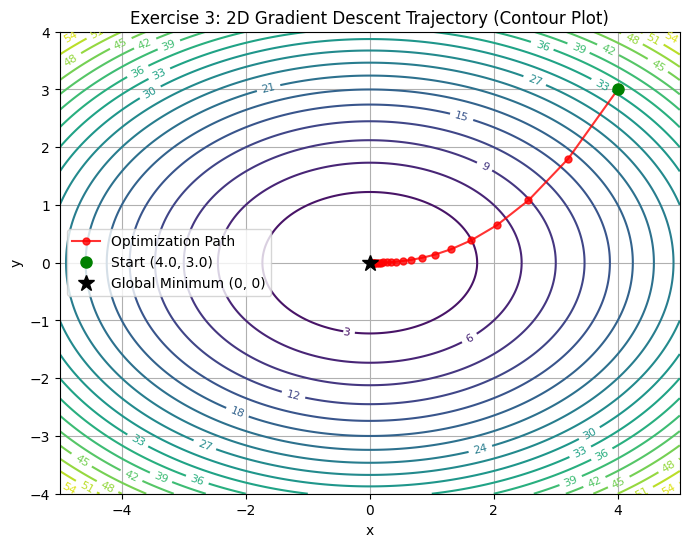

In [9]:
# contour plot visualization of 2d trajectory
x_grid = np.linspace(-5, 5, 200)
y_grid = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x_grid, y_grid)
Z = cost_function_2d(X, Y)

plt.figure(figsize=(8, 6))
contour_lines = plt.contour(X, Y, Z, levels=20, cmap="viridis")
plt.clabel(contour_lines, inline=True, fontsize=8)

plt.plot(hist_x, hist_y, "ro-", markersize=5, label="Optimization Path", alpha=0.8)
plt.plot(start_x, start_y, "go", markersize=8, label=f"Start ({start_x}, {start_y})")
plt.plot(0, 0, "k*", markersize=12, label="Global Minimum (0, 0)")

plt.title("Exercise 3: 2D Gradient Descent Trajectory (Contour Plot)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()